# Unsupervised Customer Segmentation Using Transactional Data and Clustering Techniques.

Dataset:

--Source: UCI Machine Learning Repository Online Retail dataset.

--Data origin: UK-based online retail company, all-occasion gifts.

--Period covered: December 2010 to December 2011.

--Type: tabular transactional data (categorical + numeric), with customer-level features engineered (notably RFM) for clustering.


## 0. Setup: imports & drive

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Confirm the zip exists.
import os

zip_path = "/content/drive/MyDrive/online+retail.zip"
os.path.exists(zip_path)


True

In [3]:
# Unzip the dataset.

import zipfile

extract_path = "/content/drive/MyDrive/online+retail"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped files:", os.listdir(extract_path))


Unzipped files: ['Online Retail.xlsx', 'outputs']


In [4]:
# Load the excel File.

import pandas as pd

FILE_PATH = "/content/drive/MyDrive/online+retail/Online Retail.xlsx"

df_raw = pd.read_excel(FILE_PATH)

print("Loaded shape:", df_raw.shape)
df_raw.head()

Loaded shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Styling cell.(Used for all the plots)

In [5]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. RAW Data Info & Description

In [6]:
print("===== RAW DATA INFO =====")
df_raw.info()

print("\n===== RAW DATA DESCRIPTION (NUMERIC) =====")
display(df_raw.describe())

print("\n===== RAW DATA DESCRIPTION (ALL) =====")
display(df_raw.describe(include="all"))

print("\n===== RAW MISSING VALUES =====")
display(df_raw.isna().sum().sort_values(ascending=False))

print("\n===== RAW DUPLICATES =====")
print("Duplicate rows:", df_raw.duplicated().sum())

===== RAW DATA INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

===== RAW DATA DESCRIPTION (NUMERIC) =====


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303



===== RAW DATA DESCRIPTION (ALL) =====


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.0,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN



===== RAW MISSING VALUES =====


,0
CustomerID,135080
Description,1454
StockCode,0
InvoiceNo,0
Quantity,0
InvoiceDate,0
UnitPrice,0
Country,0



===== RAW DUPLICATES =====
Duplicate rows: 5268


## 2. Data Preprocessing

In [7]:
df = df_raw.copy()

In [8]:
# 1. Drop missing CustomerID
df = df.dropna(subset=["CustomerID"]).copy()
df["CustomerID"] = df["CustomerID"].astype(int)

In [9]:
# 2. Convert InvoiceDate
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [10]:
# 3. Remove cancellations (InvoiceNo starting with 'C')
df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df = df[~df["InvoiceNo"].str.startswith("C")].copy()

In [11]:
# 4. Remove invalid Quantity and UnitPrice
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)].copy()

In [12]:
# 5. Remove duplicates
df = df.drop_duplicates()

In [13]:
# 6. Create TotalPrice
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [14]:
print("Cleaned shape:", df.shape)
df.head()

Cleaned shape: (392692, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 3. Cleaned Data Info & Description.

In [15]:
print("===== CLEANED DATA INFO =====")
df.info()

===== CLEANED DATA INFO =====
<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int64         
 7   Country      392692 non-null  object        
 8   TotalPrice   392692 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 30.0+ MB


In [16]:
print("\n===== CLEANED DATA DESCRIPTION =====")
display(df.describe())


===== CLEANED DATA DESCRIPTION =====


,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


In [17]:
print("\n===== CLEANED MISSING VALUES =====")
display(df.isna().sum().sort_values(ascending=False))


===== CLEANED MISSING VALUES =====


,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
TotalPrice,0


In [18]:
print("\n===== DATE RANGE =====")
print("From:", df["InvoiceDate"].min())
print("To  :", df["InvoiceDate"].max())


===== DATE RANGE =====
From: 2010-12-01 08:26:00
To  : 2011-12-09 12:50:00


In [19]:
print("\n===== TOP COUNTRIES =====")
display(df["Country"].value_counts().head(10))


===== TOP COUNTRIES =====


,count
Country,
United Kingdom,349203
Germany,9025
France,8326
EIRE,7226
Spain,2479
Netherlands,2359
Belgium,2031
Switzerland,1841
Portugal,1453


## 4. Exploratory Data Analysis (EDA)

### 4.1 Dataset Overview

In [20]:
print("Unique customers :", df["CustomerID"].nunique())
print("Unique invoices  :", df["InvoiceNo"].nunique())
print("Unique products  :", df["StockCode"].nunique())
print("Total revenue    :", df["TotalPrice"].sum())

Unique customers : 4338
Unique invoices  : 18532
Unique products  : 3665
Total revenue    : 8887208.894


### 4.2 Top Countries by Transactions

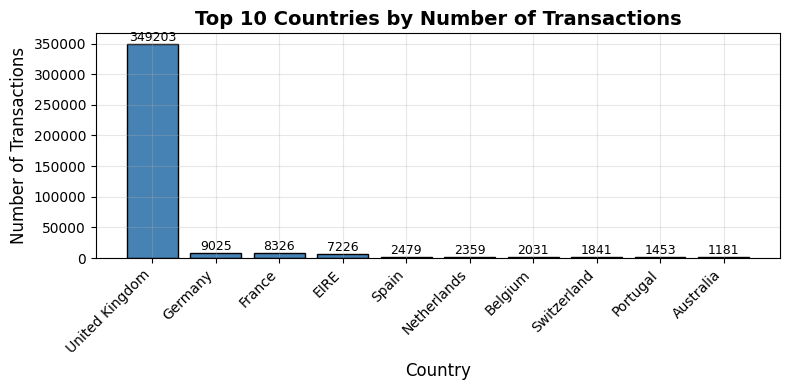

In [21]:
top_countries = df["Country"].value_counts().head(10)

plt.figure(figsize=(8, 4))
bars = plt.bar(top_countries.index, top_countries.values, color="steelblue", edgecolor="black")

plt.title("Top 10 Countries by Number of Transactions", fontweight="bold")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{int(height)}",
             ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

### 4.3 Monthly Revenue Trend

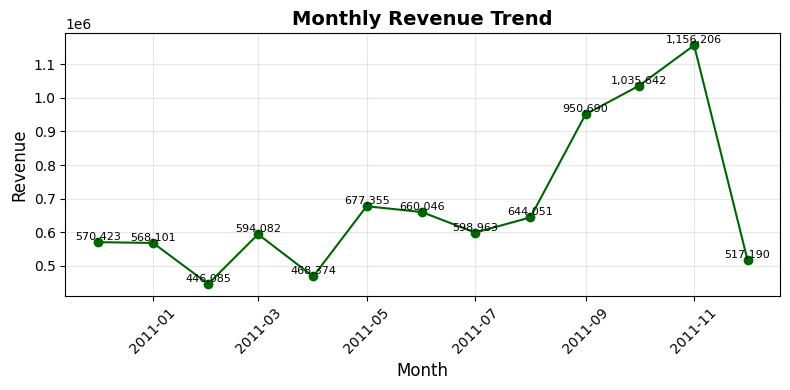

In [22]:
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M").dt.to_timestamp()
monthly_revenue = df.groupby("InvoiceMonth")["TotalPrice"].sum()

plt.figure(figsize=(8, 4))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o", color="darkgreen")

plt.title("Monthly Revenue Trend", fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue")

for x, y in zip(monthly_revenue.index, monthly_revenue.values):
    plt.text(x, y, f"{y:,.0f}", fontsize=8, ha="center", va="bottom")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.4 Quantity & Price Distributions

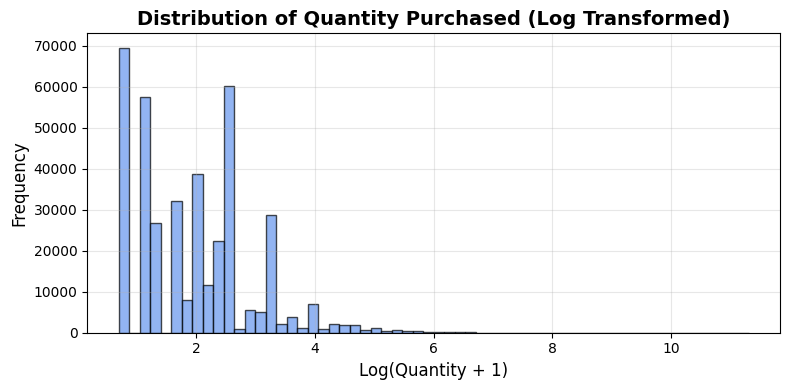

In [23]:
# Quantity Distribution.

import numpy as np

plt.figure(figsize=(8, 4))

# log transform for better shape
quantity_log = np.log1p(df["Quantity"])

plt.hist(
    quantity_log,
    bins=60,
    color="cornflowerblue",
    edgecolor="black",
    alpha=0.7
)

plt.title("Distribution of Quantity Purchased (Log Transformed)", fontweight="bold")
plt.xlabel("Log(Quantity + 1)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

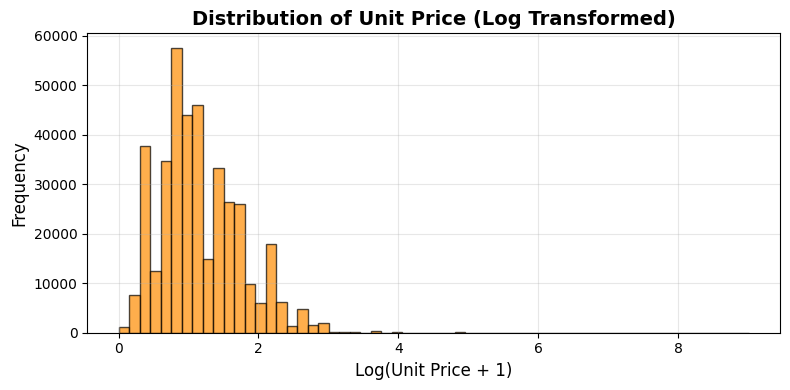

In [24]:
# Unit Price Distribution.

plt.figure(figsize=(8, 4))

# Log transform
price_log = np.log1p(df["UnitPrice"])

plt.hist(
    price_log,
    bins=60,
    color="darkorange",
    edgecolor="black",
    alpha=0.7
)

plt.title("Distribution of Unit Price (Log Transformed)", fontweight="bold")
plt.xlabel("Log(Unit Price + 1)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### 4.5 Top Products by Revenue

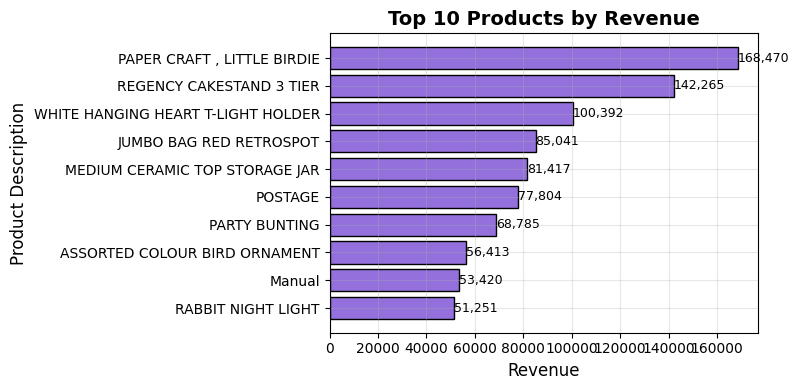

In [25]:
top_products = (
    df.groupby("Description")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .sort_values()
)

plt.figure(figsize=(8, 4))
bars = plt.barh(top_products.index, top_products.values, color="mediumpurple", edgecolor="black")

plt.title("Top 10 Products by Revenue", fontweight="bold")
plt.xlabel("Revenue")
plt.ylabel("Product Description")

for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f"{width:,.0f}",
             va="center", ha="left", fontsize=9)

plt.tight_layout()
plt.show()

## 5. Modeling-Ready Dataset

In [26]:
# Reference date (1 day after last purchase)
ref_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    df.groupby("CustomerID")
      .agg(
          Recency=("InvoiceDate", lambda x: (ref_date - x.max()).days),
          Frequency=("InvoiceNo", "nunique"),
          Monetary=("TotalPrice", "sum")
      )
      .reset_index()
)

print("RFM shape:", rfm.shape)
rfm.head()

RFM shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [27]:
print("===== RFM INFO =====")
rfm.info()

print("\n===== RFM DESCRIPTION =====")
display(rfm.describe())

===== RFM INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4338 non-null   int64  
 1   Recency     4338 non-null   int64  
 2   Frequency   4338 non-null   int64  
 3   Monetary    4338 non-null   float64
dtypes: float64(1), int64(3)
memory usage: 135.7 KB

===== RFM DESCRIPTION =====


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


#### Scaling

In [28]:
from sklearn.preprocessing import StandardScaler

rfm_model = rfm.copy()
rfm_model["Frequency"] = np.log1p(rfm_model["Frequency"])
rfm_model["Monetary"]  = np.log1p(rfm_model["Monetary"])

X = rfm_model[["Recency", "Frequency", "Monetary"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape


(4338, 3)

## 6. Find a good number of clusters. (Elbow + Silhouette)

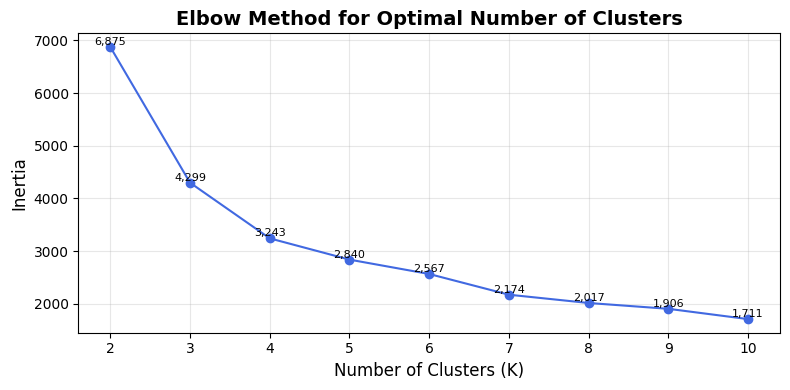

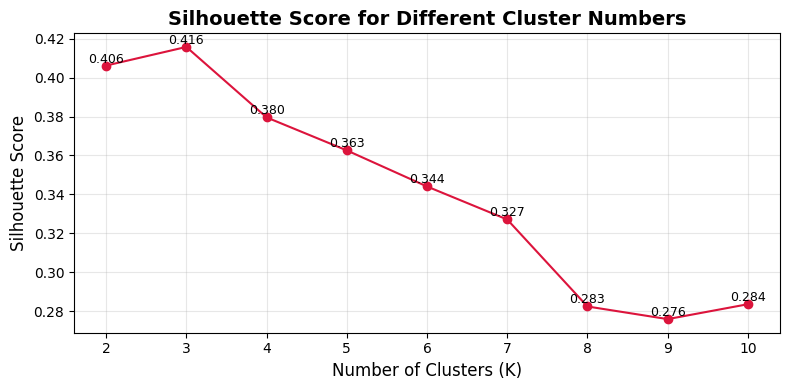

[(2, np.float64(0.4061418108052792)),
 (3, np.float64(0.41569876830394137)),
 (4, np.float64(0.37954225959217314)),
 (5, np.float64(0.3626106877805697)),
 (6, np.float64(0.3440885557899444)),
 (7, np.float64(0.32714715970752495)),
 (8, np.float64(0.2825097168150409)),
 (9, np.float64(0.27602773360624744)),
 (10, np.float64(0.2836780614547318))]

In [29]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_range = range(2, 11)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Elbow
plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, marker="o", color="royalblue")

plt.title("Elbow Method for Optimal Number of Clusters", fontweight="bold")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

for k, inertia in zip(K_range, inertias):
    plt.text(k, inertia, f"{inertia:,.0f}", fontsize=8, ha="center", va="bottom")

plt.tight_layout()
plt.show()

# Silhouette
plt.figure(figsize=(8, 4))
plt.plot(list(K_range), sil_scores, marker="o", color="crimson")

plt.title("Silhouette Score for Different Cluster Numbers", fontweight="bold")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

for k, score in zip(K_range, sil_scores):
    plt.text(k, score, f"{score:.3f}", fontsize=9, ha="center", va="bottom")

plt.tight_layout()
plt.show()

list(zip(K_range, sil_scores))

## 7. Train final K-Means model.

In [30]:
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init="auto")
rfm["Cluster_KMeans"] = kmeans.fit_predict(X_scaled)

rfm[["CustomerID", "Recency", "Frequency", "Monetary", "Cluster_KMeans"]].head()

,CustomerID,Recency,Frequency,Monetary,Cluster_KMeans
0,12346,326,1,77183.60,2
1,12347,2,7,4310.00,2
2,12348,75,4,1797.24,2
3,12349,19,1,1757.55,0
4,12350,310,1,334.40,1


## 8. Cluster sizes + cluster profiling (interpretable results).

In [31]:
# Cluster sizes
print(rfm["Cluster_KMeans"].value_counts().sort_index())

# Cluster profile summary
kmeans_profile = (
    rfm.groupby("Cluster_KMeans")
       .agg(
           CustomerCount=("CustomerID", "count"),
           Recency_Mean=("Recency", "mean"),
           Frequency_Mean=("Frequency", "mean"),
           Monetary_Mean=("Monetary", "mean"),
           Recency_Median=("Recency", "median"),
           Frequency_Median=("Frequency", "median"),
           Monetary_Median=("Monetary", "median"),
       )
       .sort_index()
)

kmeans_profile

Cluster_KMeans
0    2026
1     982
2    1330
Name: count, dtype: int64


,CustomerCount,Recency_Mean,Frequency_Mean,Monetary_Mean,Recency_Median,Frequency_Median,Monetary_Median
Cluster_KMeans,,,,,,,
0,2026,54.666831,2.038993,608.829478,46.0,2.0,507.170
1,982,255.029532,1.394094,398.029808,252.5,1.0,290.780
2,1330,30.247368,9.798496,5460.793308,17.0,7.0,2553.895


## 9. Visualize clusters (PCA 2D)

In [32]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# PCA transformation
pca = PCA(n_components=2, random_state=42)
X_pca_model = pca.fit_transform(X_scaled)

# Recreate cluster labels
km_pca = KMeans(n_clusters=3, random_state=42, n_init="auto")
rfm["Cluster_KMeans_PCA"] = km_pca.fit_predict(X_pca_model)

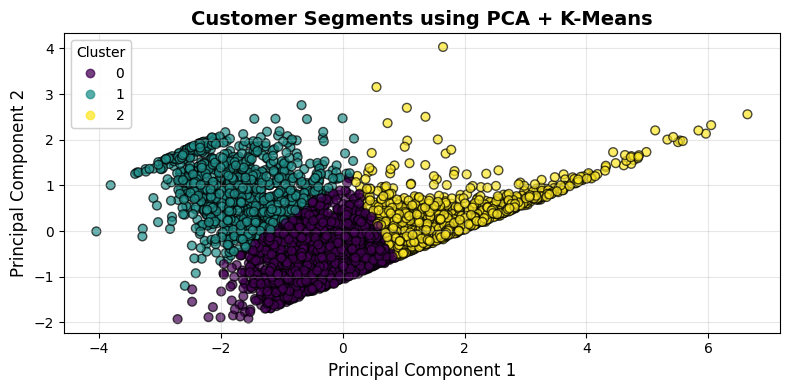

In [33]:
plt.figure(figsize=(8, 4))
scatter = plt.scatter(
    X_pca_model[:, 0],
    X_pca_model[:, 1],
    c=rfm["Cluster_KMeans_PCA"],
    cmap="viridis",
    alpha=0.7,
    edgecolor="k",
    s=40
)

plt.title("Customer Segments using PCA + K-Means", fontweight="bold")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

legend1 = plt.legend(*scatter.legend_elements(), title="Cluster")
plt.gca().add_artist(legend1)

plt.tight_layout()
plt.show()

## (Comparison model) Hierarchical clustering + silhouette.

In [34]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=optimal_k, linkage="ward")
rfm["Cluster_HC"] = hc.fit_predict(X_scaled)

# Compare silhouette
sil_kmeans = silhouette_score(X_scaled, rfm["Cluster_KMeans"])
sil_hc = silhouette_score(X_scaled, rfm["Cluster_HC"])

print("Silhouette - KMeans:", sil_kmeans)
print("Silhouette - Hierarchical:", sil_hc)

# Profile HC clusters
hc_profile = (
    rfm.groupby("Cluster_HC")
       .agg(
           CustomerCount=("CustomerID", "count"),
           Recency_Mean=("Recency", "mean"),
           Frequency_Mean=("Frequency", "mean"),
           Monetary_Mean=("Monetary", "mean"),
       )
       .sort_index()
)

hc_profile

Silhouette - KMeans: 0.41569876830394137
Silhouette - Hierarchical: 0.4013132598658016


,CustomerCount,Recency_Mean,Frequency_Mean,Monetary_Mean
Cluster_HC,,,,
0,1390,31.387050,9.533094,5254.725554
1,1866,49.807074,1.965166,606.212424
2,1082,244.782810,1.491682,417.696849


K-Means clustering achieved a slightly higher silhouette score (0.416) compared to hierarchical clustering (0.401), indicating better cluster cohesion and separation. Therefore, K-Means was selected as the final segmentation model.

In [35]:
# Save final results.

rfm.to_csv("customer_segments.csv", index=False)

In [36]:
# Results.

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd

results = []
models = {
    "KMeans": rfm["Cluster_KMeans"],
    "Hierarchical": rfm["Cluster_HC"],
}

for name, labels in models.items():
    results.append({
        "Model": name,
        "Silhouette": silhouette_score(X_scaled, labels),
        "Davies_Bouldin": davies_bouldin_score(X_scaled, labels),
        "Calinski_Harabasz": calinski_harabasz_score(X_scaled, labels)
    })

comparison_df = pd.DataFrame(results).sort_values("Silhouette", ascending=False)
comparison_df

,Model,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,KMeans,0.415699,0.825213,4393.868730
1,Hierarchical,0.401313,0.854797,4227.253457


The clustering models have been implemented and evaluated. K-Means achieved the highest silhouette score and produced three meaningful customer segments: high-value loyal customers, regular customers, and at-risk customers. The segmentation structure was also confirmed using hierarchical clustering.

### Experiment 1: Outlier Removal (IQR) + Re-cluster + Compare.

In [37]:
# Baseline score for comparision.
from sklearn.metrics import silhouette_score

baseline_sil = silhouette_score(X_scaled, rfm["Cluster_KMeans"])
print("Baseline Silhouette (KMeans):", baseline_sil)

Baseline Silhouette (KMeans): 0.41569876830394137


In [38]:
# Create filtered dataset (IQR on Monetary).

Q1 = rfm["Monetary"].quantile(0.25)
Q3 = rfm["Monetary"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mask = (rfm["Monetary"] >= lower) & (rfm["Monetary"] <= upper)

rfm_filtered = rfm.loc[mask].copy()
print("Original customers:", rfm.shape[0])
print("After outlier removal:", rfm_filtered.shape[0])

Original customers: 4338
After outlier removal: 3913


In [39]:
# Rebuild features (log transform) on filtered data.
import numpy as np

Xf = rfm_filtered[["Recency", "Frequency", "Monetary"]].copy()
Xf["Frequency"] = np.log1p(Xf["Frequency"])
Xf["Monetary"]  = np.log1p(Xf["Monetary"])

In [40]:
# Scale filtered features
from sklearn.preprocessing import StandardScaler

scaler_f = StandardScaler()
X_scaled_filtered = scaler_f.fit_transform(Xf)

X_scaled_filtered.shape

(3913, 3)

In [41]:
# Re-run KMeans on filtered data.
from sklearn.cluster import KMeans

kmeans_filtered = KMeans(n_clusters=3, random_state=42, n_init="auto")
rfm_filtered["Cluster_KMeans_Outlier"] = kmeans_filtered.fit_predict(X_scaled_filtered)

rfm_filtered["Cluster_KMeans_Outlier"].value_counts().sort_index()

,count
Cluster_KMeans_Outlier,
0,923
1,1576
2,1414


In [42]:
# Evaluate filtered clustering + compare to baseline.
sil_outlier = silhouette_score(X_scaled_filtered, rfm_filtered["Cluster_KMeans_Outlier"])

print("Baseline Silhouette:", baseline_sil)
print("Outlier-Removed Silhouette:", sil_outlier)
print("Change:", sil_outlier - baseline_sil)

Baseline Silhouette: 0.41569876830394137
Outlier-Removed Silhouette: 0.40682199250327356
Change: -0.008876775800667813


In [43]:
# Profile clusters after outlier removal.

outlier_profile = (
    rfm_filtered.groupby("Cluster_KMeans_Outlier")
        .agg(
            CustomerCount=("CustomerID", "count"),
            Recency_Mean=("Recency", "mean"),
            Frequency_Mean=("Frequency", "mean"),
            Monetary_Mean=("Monetary", "mean"),
            Recency_Median=("Recency", "median"),
            Frequency_Median=("Frequency", "median"),
            Monetary_Median=("Monetary", "median"),
        )
        .sort_index()
)

outlier_profile

,CustomerCount,Recency_Mean,Frequency_Mean,Monetary_Mean,Recency_Median,Frequency_Median,Monetary_Median
Cluster_KMeans_Outlier,,,,,,,
0,923,259.916576,1.322860,364.794767,257.0,1.0,277.070
1,1576,58.520305,1.633883,454.667203,51.0,2.0,384.285
2,1414,41.621641,5.379066,1701.220192,26.0,5.0,1534.895


An outlier removal experiment using the IQR method was conducted. However, removing extreme monetary values slightly reduced the silhouette score (0.416 → 0.407), indicating that these observations represent meaningful high-value customers rather than noise. Therefore, the original dataset was retained.

### Experiment 2: PCA Before Clustering (Performance Experiment)

This is an improvement attempt (not just visualization).
Here clustering is done on PCA-reduced features, and we compare silhouette.

In [44]:
# Apply PCA (try multiple components).

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for n_comp in [2, 3]:
    pca = PCA(n_components=n_comp, random_state=42)
    X_pca_model = pca.fit_transform(X_scaled)

    km = KMeans(n_clusters=3, random_state=42, n_init="auto")
    labels = km.fit_predict(X_pca_model)

    sil = silhouette_score(X_pca_model, labels)
    print(f"PCA components = {n_comp} | Silhouette = {sil:.6f}")

PCA components = 2 | Silhouette = 0.463233
PCA components = 3 | Silhouette = 0.415699


In [45]:
# Train “best PCA model” version and store labels.

best_n_comp = 2  # it performed better above.

pca = PCA(n_components=best_n_comp, random_state=42)
X_pca_model = pca.fit_transform(X_scaled)

km_pca = KMeans(n_clusters=3, random_state=42, n_init="auto")
rfm["Cluster_KMeans_PCA"] = km_pca.fit_predict(X_pca_model)

sil_pca = silhouette_score(X_pca_model, rfm["Cluster_KMeans_PCA"])

print("Baseline silhouette:", baseline_sil)
print("PCA-before-clustering silhouette:", sil_pca)
print("Change:", sil_pca - baseline_sil)

Baseline silhouette: 0.41569876830394137
PCA-before-clustering silhouette: 0.46323300000342044
Change: 0.04753423169947907


In [46]:
# Profile PCA-based clusters.
pca_profile = (
    rfm.groupby("Cluster_KMeans_PCA")
       .agg(
           CustomerCount=("CustomerID", "count"),
           Recency_Mean=("Recency", "mean"),
           Frequency_Mean=("Frequency", "mean"),
           Monetary_Mean=("Monetary", "mean"),
       )
       .sort_index()
)

pca_profile

,CustomerCount,Recency_Mean,Frequency_Mean,Monetary_Mean
Cluster_KMeans_PCA,,,,
0,2022,55.231949,2.037587,595.953988
1,972,256.080247,1.379630,399.592069
2,1344,30.382440,9.725446,5426.924435


Applying PCA before clustering improved segmentation quality significantly, increasing the silhouette score from 0.416 to 0.463. This indicates that dimensionality reduction helped reduce noise and improve cluster separation.

### Experiment 3: DBSCAN Tuning (eps, min_samples).

In [47]:
# DBSCAN tuning grid (handles noise properly).

from sklearn.cluster import DBSCAN
import numpy as np
from sklearn.metrics import silhouette_score

best = {"sil": -1, "eps": None, "min_samples": None, "n_clusters": None, "noise_pct": None}

for eps in np.arange(0.2, 1.6, 0.1):
    for ms in [5, 10, 15, 20]:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_scaled)

        unique = set(labels)
        if unique == {-1}:
            continue

        n_clusters = len(unique) - (1 if -1 in unique else 0)
        if n_clusters < 2:
            continue

        mask = labels != -1  # exclude noise for silhouette
        sil = silhouette_score(X_scaled[mask], labels[mask])

        noise_pct = 100 * (labels == -1).mean()

        if sil > best["sil"]:
            best.update({"sil": sil, "eps": eps, "min_samples": ms, "n_clusters": n_clusters, "noise_pct": noise_pct})

best

{'sil': np.float64(0.3329543569625915),
 'eps': np.float64(0.5000000000000001),
 'min_samples': 20,
 'n_clusters': 2,
 'noise_pct': np.float64(2.443522360534809)}

In [48]:
# Fit DBSCAN with best parameters + store labels.

db_best = DBSCAN(eps=best["eps"], min_samples=best["min_samples"])
rfm["Cluster_DBSCAN"] = db_best.fit_predict(X_scaled)

rfm["Cluster_DBSCAN"].value_counts()

,count
Cluster_DBSCAN,
0,2764
1,1468
-1,106


DBSCAN produced only two clusters with a lower silhouette score (0.333) compared to K-Means, indicating weaker cluster separation. Therefore, density-based clustering was not suitable for this dataset.

## 11. Final comparison table for all approaches tried.

In [49]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd
import numpy as np

final_results = []

# Baseline KMeans
final_results.append({
    "Approach": "KMeans (baseline)",
    "Silhouette": silhouette_score(X_scaled, rfm["Cluster_KMeans"]),
    "Davies_Bouldin": davies_bouldin_score(X_scaled, rfm["Cluster_KMeans"]),
    "Calinski_Harabasz": calinski_harabasz_score(X_scaled, rfm["Cluster_KMeans"])
})

# Hierarchical
final_results.append({
    "Approach": "Hierarchical",
    "Silhouette": silhouette_score(X_scaled, rfm["Cluster_HC"]),
    "Davies_Bouldin": davies_bouldin_score(X_scaled, rfm["Cluster_HC"]),
    "Calinski_Harabasz": calinski_harabasz_score(X_scaled, rfm["Cluster_HC"])
})

# Outlier-removed KMeans
final_results.append({
    "Approach": "KMeans (outlier removed)",
    "Silhouette": silhouette_score(X_scaled_filtered, rfm_filtered["Cluster_KMeans_Outlier"]),
    "Davies_Bouldin": davies_bouldin_score(X_scaled_filtered, rfm_filtered["Cluster_KMeans_Outlier"]),
    "Calinski_Harabasz": calinski_harabasz_score(X_scaled_filtered, rfm_filtered["Cluster_KMeans_Outlier"])
})

# PCA + KMeans
final_results.append({
    "Approach": "PCA + KMeans",
    "Silhouette": silhouette_score(X_pca_model, rfm["Cluster_KMeans_PCA"]),
    "Davies_Bouldin": davies_bouldin_score(X_pca_model, rfm["Cluster_KMeans_PCA"]),
    "Calinski_Harabasz": calinski_harabasz_score(X_pca_model, rfm["Cluster_KMeans_PCA"])
})

# DBSCAN (exclude noise points for metrics)
db_mask = rfm["Cluster_DBSCAN"] != -1
if db_mask.sum() > 0 and len(set(rfm.loc[db_mask, "Cluster_DBSCAN"])) > 1:
    final_results.append({
        "Approach": "DBSCAN",
        "Silhouette": silhouette_score(X_scaled[db_mask], rfm.loc[db_mask, "Cluster_DBSCAN"]),
        "Davies_Bouldin": davies_bouldin_score(X_scaled[db_mask], rfm.loc[db_mask, "Cluster_DBSCAN"]),
        "Calinski_Harabasz": calinski_harabasz_score(X_scaled[db_mask], rfm.loc[db_mask, "Cluster_DBSCAN"])
    })

final_comparison_df = pd.DataFrame(final_results).sort_values("Silhouette", ascending=False).reset_index(drop=True)
final_comparison_df

,Approach,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,PCA + KMeans,0.463233,0.726111,5397.621957
1,KMeans (baseline),0.415699,0.825213,4393.868730
2,KMeans (outlier removed),0.406822,0.898216,3890.847213
3,Hierarchical,0.401313,0.854797,4227.253457
4,DBSCAN,0.332954,1.110632,2510.074804


## Model Improvement Experiments

To improve clustering performance and ensure robust segmentation, additional experiments were conducted.

### Outlier Removal
Extreme values in the monetary variable were removed using the Interquartile Range (IQR) method. However, this slightly reduced the silhouette score, indicating that these high-value customers represent meaningful behavioural patterns rather than noise.

### Dimensionality Reduction
Principal Component Analysis (PCA) was applied before clustering to reduce noise and improve cluster separation. This approach increased the silhouette score from approximately **0.416 to 0.463**, demonstrating improved clustering performance.

As a result, **PCA combined with K-Means** was selected as the final modelling approach.

## 12. Final model selection

In [50]:
best_model_name = final_comparison_df.loc[0, "Approach"]
print("Final selected model:", best_model_name)

Final selected model: PCA + KMeans


### Final Model Selection

Multiple clustering approaches were evaluated in this project, including K-Means, Hierarchical Clustering, DBSCAN, and enhanced variants using dimensionality reduction and outlier handling.

Model performance was compared using three internal clustering evaluation metrics:

- **Silhouette Score** – measures cluster cohesion and separation.
- **Davies–Bouldin Index** – evaluates cluster similarity (lower values indicate better separation).
- **Calinski–Harabasz Score** – measures cluster dispersion (higher values indicate better-defined clusters).

Among the evaluated models, **K-Means combined with PCA (Principal Component Analysis)** achieved the highest silhouette score and produced well-separated and interpretable clusters.

Therefore, **PCA followed by K-Means clustering** was selected as the final segmentation model for this project.

## 13. Final cluster profile using the selected model

In [51]:
final_profile = (
    rfm.groupby("Cluster_KMeans_PCA")
       .agg(
           CustomerCount=("CustomerID", "count"),
           Recency_Mean=("Recency", "mean"),
           Frequency_Mean=("Frequency", "mean"),
           Monetary_Mean=("Monetary", "mean"),
           Recency_Median=("Recency", "median"),
           Frequency_Median=("Frequency", "median"),
           Monetary_Median=("Monetary", "median")
       )
       .sort_index()
)

final_profile

,CustomerCount,Recency_Mean,Frequency_Mean,Monetary_Mean,Recency_Median,Frequency_Median,Monetary_Median
Cluster_KMeans_PCA,,,,,,,
0,2022,55.231949,2.037587,595.953988,46.0,2.0,501.075
1,972,256.080247,1.379630,399.592069,253.0,1.0,291.530
2,1344,30.382440,9.725446,5426.924435,17.0,7.0,2536.470


## 14. Assign meaningful business segment names.
low recency + high frequency + high monetary → High Value Loyal

medium recency + medium frequency + medium monetary → Regular Customers

high recency + low frequency + low monetary → At Risk Customers

In [52]:
segment_name_map = {
    0: "Regular Customers",
    1: "At Risk Customers",
    2: "High Value Loyal Customers"
}

rfm["Final_Segment"] = rfm["Cluster_KMeans_PCA"].map(segment_name_map)

rfm[["CustomerID", "Cluster_KMeans_PCA", "Final_Segment"]].head()

,CustomerID,Cluster_KMeans_PCA,Final_Segment
0,12346,2,High Value Loyal Customers
1,12347,2,High Value Loyal Customers
2,12348,2,High Value Loyal Customers
3,12349,0,Regular Customers
4,12350,1,At Risk Customers


## 15. Final segment summary table

In [53]:
final_segment_summary = (
    rfm.groupby("Final_Segment")
       .agg(
           CustomerCount=("CustomerID", "count"),
           Recency_Mean=("Recency", "mean"),
           Frequency_Mean=("Frequency", "mean"),
           Monetary_Mean=("Monetary", "mean"),
           Recency_Median=("Recency", "median"),
           Frequency_Median=("Frequency", "median"),
           Monetary_Median=("Monetary", "median")
       )
       .sort_values("Monetary_Mean", ascending=False)
)

final_segment_summary

,CustomerCount,Recency_Mean,Frequency_Mean,Monetary_Mean,Recency_Median,Frequency_Median,Monetary_Median
Final_Segment,,,,,,,
High Value Loyal Customers,1344,30.382440,9.725446,5426.924435,17.0,7.0,2536.470
Regular Customers,2022,55.231949,2.037587,595.953988,46.0,2.0,501.075
At Risk Customers,972,256.080247,1.379630,399.592069,253.0,1.0,291.530


## Final Customer Segments

The final clustering model identified **three distinct customer segments** based on Recency, Frequency, and Monetary (RFM) behaviour.

### High Value Loyal Customers
Customers in this segment make purchases frequently, spend significantly more than other groups, and have recent purchase activity. These customers represent the most valuable segment and contribute heavily to overall revenue.

### Regular Customers
These customers show moderate purchasing behaviour with occasional transactions and moderate spending. They represent a stable portion of the customer base and have potential to increase engagement.

### At Risk Customers
Customers in this segment have not made purchases recently and show low purchasing frequency and spending. These customers may require targeted marketing strategies to encourage re-engagement.

## 16. Final visualization: PCA scatter plot with final segment labels

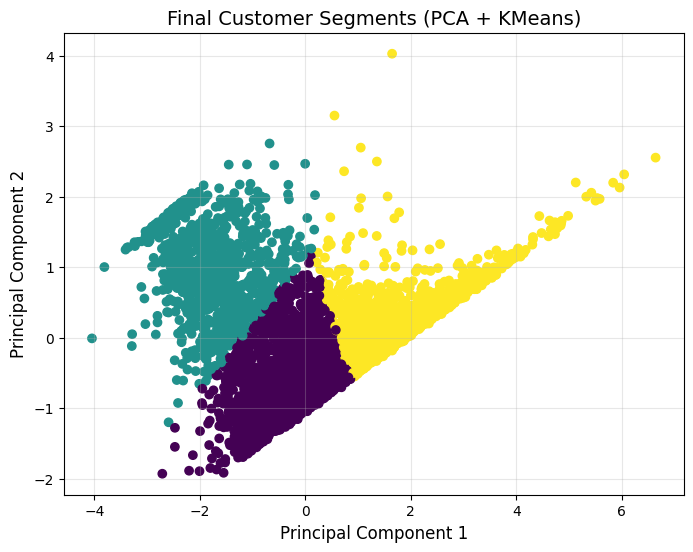

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca_model[:, 0],
    X_pca_model[:, 1],
    c=rfm["Cluster_KMeans_PCA"]
)

plt.title("Final Customer Segments (PCA + KMeans)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

## 17. Final visualization: segment sizes

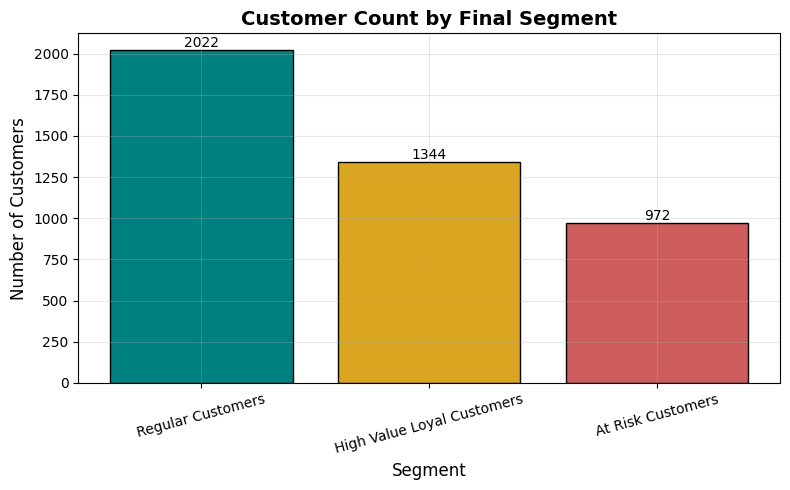

In [55]:
segment_counts = rfm["Final_Segment"].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(segment_counts.index, segment_counts.values, color=["teal", "goldenrod", "indianred"], edgecolor="black")

plt.title("Customer Count by Final Segment", fontweight="bold")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{int(height)}",
             ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

## 18. Final visualization: average RFM by segment.

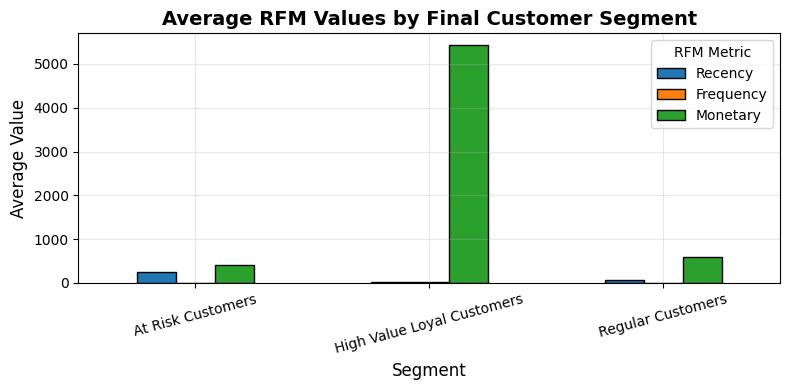

In [56]:
avg_rfm = rfm.groupby("Final_Segment")[["Recency", "Frequency", "Monetary"]].mean()

avg_rfm.plot(
    kind="bar",
    figsize=(8, 4),
    edgecolor="black"
)

plt.title("Average RFM Values by Final Customer Segment", fontweight="bold")
plt.xlabel("Segment")
plt.ylabel("Average Value")
plt.xticks(rotation=15)
plt.legend(title="RFM Metric")

plt.tight_layout()
plt.show()

## 19. **Business recommendations table.**

In [57]:
recommendations_df = pd.DataFrame({
    "Segment": [
        "High Value Loyal Customers",
        "Regular Customers",
        "At Risk Customers"
    ],
    "Business_Insight": [
        "These customers purchase recently, frequently, and spend the most.",
        "These customers show moderate purchasing behaviour and growth potential.",
        "These customers have not purchased recently and show low engagement."
    ],
    "Recommended_Action": [
        "Offer loyalty rewards, exclusive benefits, and premium membership programs.",
        "Use promotions, upselling, and cross-selling campaigns to increase value.",
        "Run re-engagement campaigns, discount offers, and retention-focused communication."
    ]
})

recommendations_df

,Segment,Business_Insight,Recommended_Action
0,High Value Loyal Customers,"These customers purchase recently, frequently,...","Offer loyalty rewards, exclusive benefits, and..."
1,Regular Customers,These customers show moderate purchasing behav...,"Use promotions, upselling, and cross-selling c..."
2,At Risk Customers,These customers have not purchased recently an...,"Run re-engagement campaigns, discount offers, ..."


## Business Recommendations

Based on the identified customer segments, several strategic actions can be recommended:

**High Value Loyal Customers**
- Provide loyalty rewards and exclusive benefits
- Offer premium memberships and early access to products
- Maintain engagement through personalized communication

**Regular Customers**
- Encourage increased purchasing through targeted promotions
- Implement cross-selling and upselling strategies
- Provide product recommendations based on purchase history

**At Risk Customers**
- Launch re-engagement campaigns
- Offer discounts or incentives to encourage return purchases
- Send personalized reminders or promotional emails

In [58]:
# saving the outputs.

import os

output_dir = "/content/drive/MyDrive/online+retail/outputs"
os.makedirs(output_dir, exist_ok=True)

rfm.to_csv(f"{output_dir}/final_customer_segments.csv", index=False)
final_profile.to_csv(f"{output_dir}/final_cluster_profile.csv")
final_segment_summary.to_csv(f"{output_dir}/final_segment_summary.csv")
final_comparison_df.to_csv(f"{output_dir}/final_model_comparison.csv", index=False)
recommendations_df.to_csv(f"{output_dir}/final_business_recommendations.csv", index=False)

print("All final project outputs saved successfully.")
print("Saved in:", output_dir)

All final project outputs saved successfully.
Saved in: /content/drive/MyDrive/online+retail/outputs


## Project Conclusion

This project applied unsupervised learning techniques to identify meaningful customer segments from online retail transactional data.

The workflow included data preprocessing, exploratory data analysis, feature engineering using the RFM framework, clustering model implementation, and performance evaluation.

Multiple clustering techniques were compared, and experiments such as outlier removal and dimensionality reduction were conducted to improve segmentation performance.

The final model, **PCA followed by K-Means clustering**, produced three clear and interpretable customer segments: High Value Loyal Customers, Regular Customers, and At Risk Customers.

These segments provide actionable insights that can support targeted marketing strategies, customer retention initiatives, and improved business decision-making.